In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seed 
np.random.seed(42)

In [2]:
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)
sns.set_palette("Spectral", n_colors=12)

# Handling the data

In [3]:
# Load the data
df = pd.read_csv("data/proportionsPKH26-EVIR.csv", sep = ';', decimal = ',')

In [4]:
df_means_std = pd.read_csv("data/proportionsPKH26_EVIR_mean_std.csv", sep = ";", decimal=",").iloc[:18]
df_means_std.drop("Unnamed: 0", axis=1, inplace=True)
df_means_std = df_means_std.fillna(0)


In [5]:
# Delete lines for the US samples
df_means_std = df_means_std[df_means_std["Name"] != "US"]

# Figures

### Proportions of EVIR and PKH26 over all cells

In [6]:
# Mean
two_hours_df_mean = (
    df.groupby("Time point")[["EVIR+", "EVIR-", "PKH26+", "PKH26-"]]
      .mean()
      .reset_index()
)

# Standard deviation
two_hours_df_std = (
    df.groupby("Time point")[["EVIR+", "EVIR-", "PKH26+", "PKH26-"]]
      .std()
      .reset_index()
)

mean_long = two_hours_df_mean.melt(
    id_vars="Time point",
    var_name="Readout",
    value_name="Mean"
)

std_long = two_hours_df_std.melt(
    id_vars="Time point",
    var_name="Readout",
    value_name="SD"
)

# Merge mean + SD
plot_df = mean_long.merge(
    std_long,
    on=["Time point", "Readout"]
)


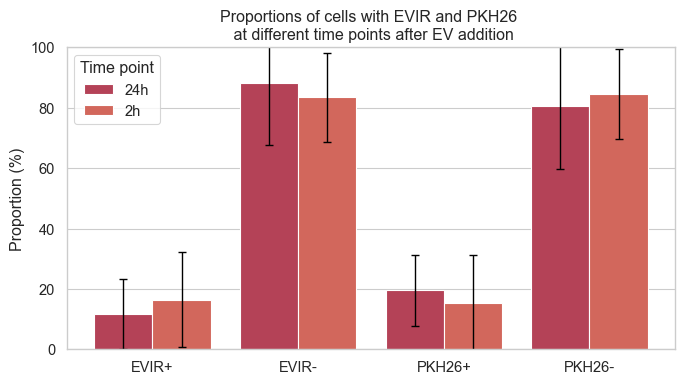

In [7]:
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=plot_df,
    x="Readout",
    y="Mean",
    hue="Time point",
)

# Add SD error bars manually
plot_df_sorted = plot_df.sort_values(["Readout", "Time point"]).reset_index(drop=True)

for patch, (_, row) in zip(ax.patches, plot_df_sorted.iterrows()):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    ax.errorbar(
        x, y,
        yerr=row["SD"],
        fmt="none",
        capsize=3,
        linewidth=1,
        color="black"
    )

ax.set_ylim(0, 100)
ax.set_ylabel("Proportion (%)")
ax.set_xlabel("")
ax.set_title("Proportions of cells with EVIR and PKH26 \n at different time points after EV addition")
plt.tight_layout();

## Proportions of PKH26+ cells

In [8]:
df_means_std

,Time point,Name,Transfected,EVs,Frozen,EVIR+,EVIR+ (std),EVIR-,EVIR- (std),PKH26+,PKH26+ (std),PKH26-,PKH26- (std)
1,2h,EVIR GD2+,1.0,1.0,0.0,25.066667,5.601190,74.933333,5.601190,2.590,1.976841,97.40,1.969772
2,2h,EVIR GD2-,1.0,0.0,0.0,27.950000,1.344000,72.050000,1.344000,0.930,0.297000,99.10,0.283000
3,2h,UT GD2+,0.0,1.0,0.0,1.402000,0.373323,98.620000,0.363318,34.180,9.102033,65.82,9.102033
4,2h,UT GD2-,0.0,0.0,0.0,1.350000,0.000000,98.700000,0.000000,9.630,0.000000,90.40,0.000000
5,2h,EVIR GD2+,1.0,1.0,1.0,56.500000,3.394113,43.500000,3.394113,7.295,0.869741,92.70,0.848528
6,2h,EVIR GD2-,1.0,0.0,1.0,54.000000,0.000000,46.000000,0.000000,1.270,0.000000,98.70,0.000000
7,2h,UT GD2+,0.0,1.0,1.0,1.960000,0.622254,98.050000,0.636396,28.550,1.343503,71.45,1.343503
8,2h,UT GD2-,0.0,0.0,1.0,1.810000,0.381838,98.200000,0.424264,14.900,1.555635,85.10,1.555635
10,24h,EVIR GD2+,1.0,1.0,0.0,19.950000,0.494975,80.050000,0.494975,25.950,3.606245,74.05,3.606245
11,24h,EVIR GD2-,1.0,0.0,0.0,23.100000,1.979899,76.900000,1.979899,1.290,0.070711,98.75,0.070711


In [9]:
palette = sns.color_palette("Spectral", 12)


In [16]:

def plot_panel(data, axis, title, marker):
    sns.barplot(
        data=data,
        x="Name",
        y=marker,
        hue="Frozen",
        errorbar=None,
        palette=("#FF6F61", "#0887A0"),
        saturation=1,
        ax=axis
    )

    # Add error bars manually
    for container, frozen_val in zip(axis.containers, sorted(data["Frozen"].unique())):
        subset = data[data["Frozen"] == frozen_val].reset_index(drop=True)
        for bar, (_, row) in zip(container, subset.iterrows()):
            x = bar.get_x() + bar.get_width() / 2
            axis.errorbar(
                x,
                row[marker],
                yerr=row[marker + " (std)"],
                fmt="none",
                ecolor="black",
                capsize=4,
                linewidth=1
            )

    axis.set_title(title + " after EVs addition")
    axis.set_xlabel("Sample")
    axis.set_ylabel(marker + " (%)")
    axis.set_ylim(0, 100)
    axis.tick_params(axis="x", rotation=45)
    axis.legend(title="Frozen", labels=["No", "Yes"])

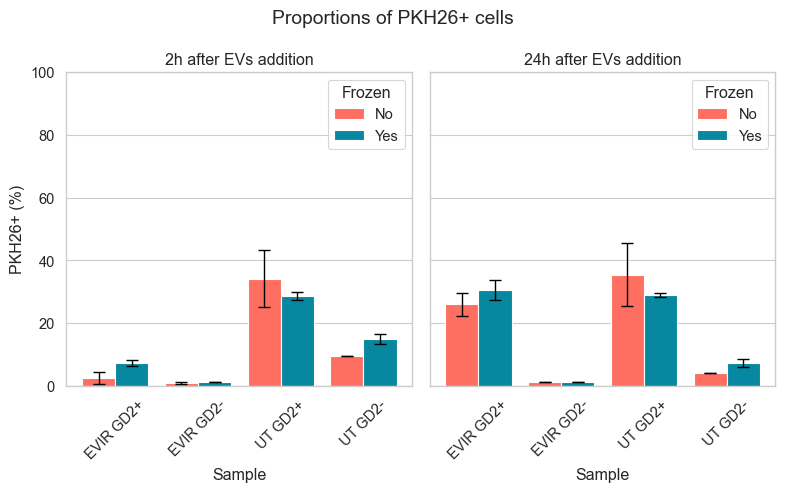

In [17]:
# Split by time point
df_2h  = df_means_std[df_means_std["Time point"] == "2h"]
df_24h = df_means_std[df_means_std["Time point"] == "24h"]

fig, ax = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

plot_panel(df_2h,  ax[0], "2h", "PKH26+")
plot_panel(df_24h, ax[1], "24h", "PKH26+")

plt.suptitle("Proportions of PKH26+ cells")
plt.tight_layout()
plt.savefig("Figures/assessing_function/proportionPKH26");

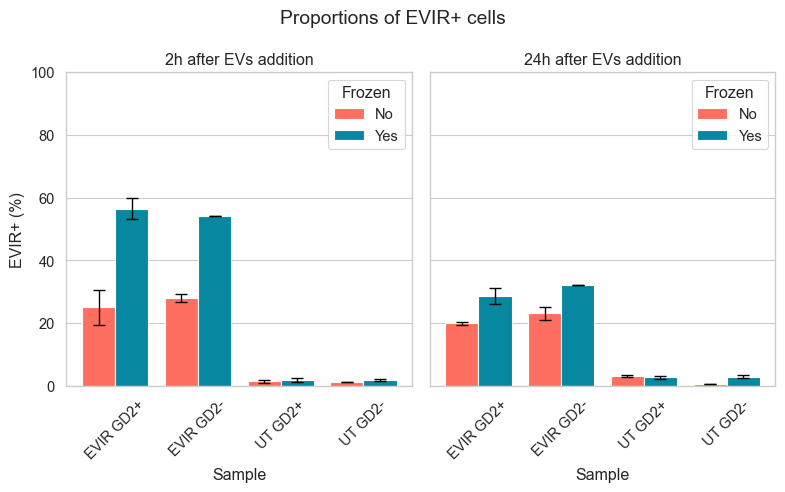

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

plot_panel(df_2h,  ax[0], "2h", "EVIR+")
plot_panel(df_24h, ax[1], "24h", "EVIR+")

plt.suptitle("Proportions of EVIR+ cells")
plt.tight_layout()
plt.savefig("Figures/assessing_function/proportionEVIR");